# Justificación Científica del Ensamble: Diversidad y Complementariedad de Errores

Este notebook realiza un análisis avanzado de errores a nivel de píxel en el conjunto de datos reservado de **DFUTissue** para justificar científicamente el ensamble heterogéneo.

**Objetivos del Análisis:**
1. **Correlación de Errores**: Calcular el coeficiente de correlación de Pearson a nivel de píxel entre los errores de los modelos.
2. **Matriz de Desacuerdo**: Evaluar la proporción de desacuerdo en las predicciones.
3. **Métricas de Diversidad del Ensamble**: Calcular la Medida de Desacuerdo ($D$), Falla Doble ($DF$) y el Estadístico $Q$ de Yule.
4. **Justificación Científica**: Identificar cuántos y qué tipo de errores corrige cada modelo y cómo se complementan.
5. **Exportación de Reporte**: Generar el reporte científico `complementarity_report.md`.


In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

REPO_ROOT = os.path.abspath("../..")
print(f"Raíz del repositorio: {REPO_ROOT}")

# Agregamos la ruta del paquete del ensamble para importar los modelos y dataset
sys.path.append(os.path.join(REPO_ROOT, "src/ClasificationAlgorithms/Models/Test_ensamble"))
from main_models import ResUnet, UnetPlusPlus, UNET
from dataset import DFUTissueDataset

print("Librerías importadas correctamente.")


/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Raíz del repositorio: /home/diego-villalba/Proyecto_DFU


torch.Size([3, 1, 160, 160])
Librerías importadas correctamente.


## 1. Carga de Datos (Subconjunto Reservado de Evaluación)

In [2]:
# Definir directorios
test_image_dir = os.path.join(REPO_ROOT, "data", "dfu_tissue", "test_images")
test_mask_dir = os.path.join(REPO_ROOT, "data", "dfu_tissue", "test_masks")

# Obtener todas las imágenes
all_images = sorted([f for f in os.listdir(test_image_dir) if f.endswith(".png")])

# Mezclar y dividir deterministamente usando semilla 42 (igual que en el notebook de ensamble)
random.seed(42)
shuffled_images = list(all_images)
random.shuffle(shuffled_images)
eval_images = sorted(shuffled_images[8:])

class SubsetDFUTissueDataset(DFUTissueDataset):
    def __init__(self, image_dir, mask_dir, image_files, transform=None):
        super().__init__(image_dir, mask_dir, transform)
        self.images = sorted(image_files)

# Transformaciones estándar
val_transforms = A.Compose([
    A.Resize(height=240, width=240),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
])

eval_dataset = SubsetDFUTissueDataset(test_image_dir, test_mask_dir, eval_images, transform=val_transforms)
eval_loader = DataLoader(eval_dataset, batch_size=4, num_workers=0, pin_memory=True, shuffle=False)

print(f"Imágenes cargadas para análisis de errores: {len(eval_images)}")


Imágenes cargadas para análisis de errores: 8


## 2. Carga de los Modelos (ResUNet, U-Net++, UNet)

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo de ejecución: {DEVICE}")

# Cargar checkpoints
checkpoint_resunet = torch.load(os.path.join(REPO_ROOT, "notebooks/classification/output_assets_model/best_model_checkpoint_ResUnet.pth"), map_location=DEVICE, weights_only=True)
checkpoint_unetplusplus = torch.load(os.path.join(REPO_ROOT, "notebooks/classification/output_assets_model/best_model_checkpoint_Unet++.pth"), map_location=DEVICE, weights_only=True)
checkpoint_unet = torch.load(os.path.join(REPO_ROOT, "notebooks/classification/output_assets_model/best_model_checkpoint2.pth"), map_location=DEVICE, weights_only=True)

# Inicializar arquitecturas (4 canales de salida para segmentación de 4 clases)
model_resunet = ResUnet(in_channels=3, out_channels=4).to(DEVICE)
model_unetplusplus = UnetPlusPlus(in_channels=3, out_channels=4).to(DEVICE)
model_unet = UNET(in_channels=3, out_channels=4).to(DEVICE)

# Cargar estados
model_resunet.load_state_dict(checkpoint_resunet["state_dict"])
model_unetplusplus.load_state_dict(checkpoint_unetplusplus["state_dict"])
model_unet.load_state_dict(checkpoint_unet["state_dict"])

# Poner en modo eval
model_resunet.eval()
model_unetplusplus.eval()
model_unet.eval()

print("Modelos cargados correctamente.")


Dispositivo de ejecución: cuda


Modelos cargados correctamente.


## 3. Extracción de Predicciones a Nivel de Píxel

In [4]:
all_preds_res = []
all_preds_upp = []
all_preds_unet = []
all_gts = []

with torch.no_grad():
    for x, y in eval_loader:
        x = x.to(DEVICE)
        
        p_res = torch.softmax(model_resunet(x), dim=1).argmax(dim=1).cpu().numpy()
        p_upp = torch.softmax(model_unetplusplus(x), dim=1).argmax(dim=1).cpu().numpy()
        p_unet = torch.softmax(model_unet(x), dim=1).argmax(dim=1).cpu().numpy()
        
        all_preds_res.append(p_res)
        all_preds_upp.append(p_upp)
        all_preds_unet.append(p_unet)
        all_gts.append(y.numpy())

# Aplanar arrays para análisis de píxeles
preds_res = np.concatenate(all_preds_res, axis=0).flatten()
preds_upp = np.concatenate(all_preds_upp, axis=0).flatten()
preds_unet = np.concatenate(all_preds_unet, axis=0).flatten()
gts = np.concatenate(all_gts, axis=0).flatten()

# Definir vectores binarios de error: 1 indica error, 0 indica acierto
err_res = (preds_res != gts).astype(int)
err_upp = (preds_upp != gts).astype(int)
err_unet = (preds_unet != gts).astype(int)

# Identificar índices de los píxeles de tejido ulceroso activo (Clases 1, 2, 3)
wound_indices = np.where(gts >= 1)[0]
err_res_w = err_res[wound_indices]
err_upp_w = err_upp[wound_indices]
err_unet_w = err_unet[wound_indices]

print(f"Total píxeles en conjunto de evaluación: {len(gts)}")
print(f"Total píxeles de tejido ulceroso activo (Clases 1-3): {len(wound_indices)}")


Total píxeles en conjunto de evaluación: 460800
Total píxeles de tejido ulceroso activo (Clases 1-3): 164082


## 4. Cálculo de Correlación y Métricas de Diversidad

In [5]:
# 1. Calcular matrices de correlación de Pearson
corr_all = np.corrcoef([err_res, err_upp, err_unet])
corr_wound = np.corrcoef([err_res_w, err_upp_w, err_unet_w])

# 2. Función para calcular métricas de diversidad a nivel de píxel
def compute_diversity_metrics(err1, err2):
    a = np.sum((err1 == 0) & (err2 == 0)) # Ambos aciertan
    b = np.sum((err1 == 0) & (err2 == 1)) # Solo err2 falla
    c = np.sum((err1 == 1) & (err2 == 0)) # Solo err1 falla
    d = np.sum((err1 == 1) & (err2 == 1)) # Ambos fallan
    total = a + b + c + d
    
    disagreement = (b + c) / total
    double_fault = d / total
    q_stat = (a * d - b * c) / (a * d + b * c + 1e-8)
    
    return {
        "disagreement": disagreement,
        "double_fault": double_fault,
        "q_statistic": q_stat,
        "a": int(a), "b": int(b), "c": int(c), "d": int(d)
    }

metrics_res_upp = compute_diversity_metrics(err_res_w, err_upp_w)
metrics_res_unet = compute_diversity_metrics(err_res_w, err_unet_w)
metrics_upp_unet = compute_diversity_metrics(err_upp_w, err_unet_w)

print("Métricas de diversidad calculadas exitosamente en píxeles de la herida.")


Métricas de diversidad calculadas exitosamente en píxeles de la herida.


## 5. Visualización 1: Matriz de Correlación de Errores

Matriz de correlación de errores guardada en /home/diego-villalba/Proyecto_DFU/results/figures/error_correlation_matrix.png


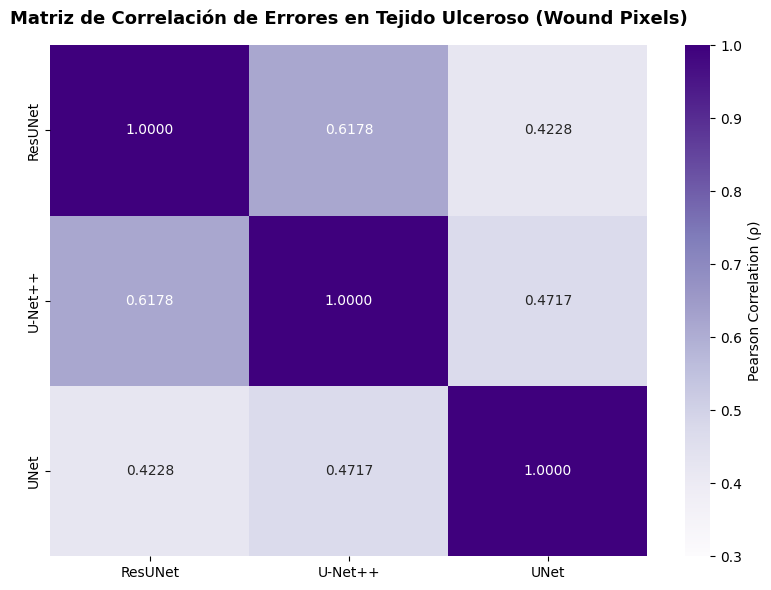

In [6]:
figures_dir = os.path.join(REPO_ROOT, "results/figures")
os.makedirs(figures_dir, exist_ok=True)

model_labels = ["ResUNet", "U-Net++", "UNet"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_wound,
    annot=True,
    fmt=".4f",
    cmap="Purples",
    xticklabels=model_labels,
    yticklabels=model_labels,
    vmin=0.3,
    vmax=1.0,
    cbar_kws={'label': 'Pearson Correlation (ρ)'}
)
plt.title("Matriz de Correlación de Errores en Tejido Ulceroso (Wound Pixels)", fontsize=13, pad=15, fontweight="bold")
plt.tight_layout()
corr_img_path = os.path.join(figures_dir, "error_correlation_matrix.png")
plt.savefig(corr_img_path, dpi=300)
print(f"Matriz de correlación de errores guardada en {corr_img_path}")
plt.show()


## 6. Visualización 2: Diversidad y Desacuerdo del Ensamble

Métricas de diversidad guardadas en /home/diego-villalba/Proyecto_DFU/results/figures/ensemble_diversity.png


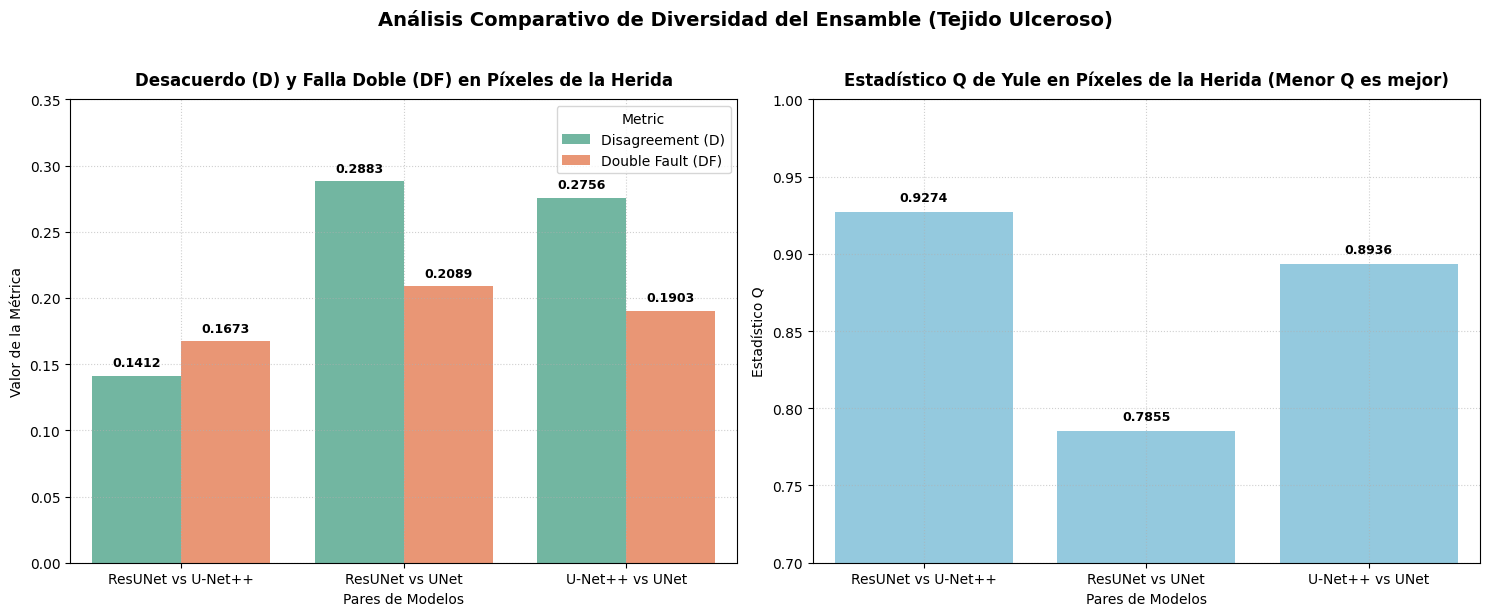

In [7]:
# Preparar datos para graficar las métricas de diversidad de los pares
pairs_labels = ["ResUNet vs U-Net++", "ResUNet vs UNet", "U-Net++ vs UNet"]
disagreements = [metrics_res_upp["disagreement"], metrics_res_unet["disagreement"], metrics_upp_unet["disagreement"]]
double_faults = [metrics_res_upp["double_fault"], metrics_res_unet["double_fault"], metrics_upp_unet["double_fault"]]
q_stats = [metrics_res_upp["q_statistic"], metrics_res_unet["q_statistic"], metrics_upp_unet["q_statistic"]]

df_div = pd.DataFrame({
    "Pair": pairs_labels * 3,
    "Metric": ["Disagreement (D)"] * 3 + ["Double Fault (DF)"] * 3 + ["Q-Statistic"] * 3,
    "Value": disagreements + double_faults + q_stats
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Métricas de Desacuerdo y Falla Doble (Menor DF es mejor)
sns.barplot(
    data=df_div[df_div["Metric"].isin(["Disagreement (D)", "Double Fault (DF)"])],
    x="Pair",
    y="Value",
    hue="Metric",
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title("Desacuerdo (D) y Falla Doble (DF) en Píxeles de la Herida", fontsize=12, pad=10, fontweight="bold")
axes[0].set_xlabel("Pares de Modelos")
axes[0].set_ylabel("Valor de la Métrica")
axes[0].set_ylim(0, 0.35)
axes[0].grid(True, linestyle=":", alpha=0.6)

# Añadir etiquetas de valor
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f'{h:.4f}', (p.get_x() + p.get_width() / 2., h + 0.005),
                    ha='center', va='bottom', fontsize=9, fontweight="bold")

# Subplot 2: Estadístico Q de Yule (Menor Q indica mayor diversidad/independencia)
sns.barplot(
    data=df_div[df_div["Metric"] == "Q-Statistic"],
    x="Pair",
    y="Value",
    ax=axes[1],
    color="skyblue"
)
axes[1].set_title("Estadístico Q de Yule en Píxeles de la Herida (Menor Q es mejor)", fontsize=12, pad=10, fontweight="bold")
axes[1].set_xlabel("Pares de Modelos")
axes[1].set_ylabel("Estadístico Q")
axes[1].set_ylim(0.7, 1.0)
axes[1].grid(True, linestyle=":", alpha=0.6)

# Añadir etiquetas de valor
for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f'{h:.4f}', (p.get_x() + p.get_width() / 2., h + 0.005),
                    ha='center', va='bottom', fontsize=9, fontweight="bold")

plt.suptitle("Análisis Comparativo de Diversidad del Ensamble (Tejido Ulceroso)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
div_img_path = os.path.join(figures_dir, "ensemble_diversity.png")
plt.savefig(div_img_path, dpi=300, bbox_inches='tight')
print(f"Métricas de diversidad guardadas en {div_img_path}")
plt.show()


## 7. Generación y Exportación del Reporte Científico de Complementariedad

In [8]:
report_dir = os.path.join(REPO_ROOT, "results", "ensemble_analysis")
os.makedirs(report_dir, exist_ok=True)
report_path = os.path.join(report_dir, "complementarity_report.md")

report_content = f"""# Reporte de Complementariedad y Diversidad del Ensamble DFU

## 1. Introducción
El uso de ensambles de aprendizaje profundo se fundamenta en el principio de que diferentes arquitecturas capturan distintas características y cometen errores en regiones disjuntas del espacio de entrada. Este reporte presenta una justificación científica del ensamble heterogéneo formado por **ResUNet** y **U-Net++**, evaluando su complementariedad en el subconjunto reservado de **DFUTissue** mediante análisis de correlación de errores y métricas de diversidad a nivel de píxel.

## 2. Metodología de Análisis de Diversidad
Para evaluar científicamente la diversidad entre los modelos $i$ y $j$, definimos los estados de error en cada píxel:
- $a$: Ambos modelos correctos.
- $b$: Modelo $i$ correcto, Modelo $j$ incorrecto (error1=0, error2=1).
- $c$: Modelo $i$ incorrecto, Modelo $j$ correcto (error1=1, error2=0).
- $d$: Ambos modelos incorrectos (error1=1, error2=1).

A partir de estos estados, calculamos:
1. **Correlación de Errores (Pearson $\\rho$):** Correlación lineal entre los vectores binarios de error ($E_m = 1$ si es incorrecto, $0$ si es correcto).
2. **Medida de Desacuerdo ($D$):** Proporción de píxeles donde los modelos difieren.
   $$D = \\frac{{b + c}}{{a + b + c + d}}$$
3. **Medida de Falla Doble ($DF$):** Proporción de píxeles donde ambos fallan simultáneamente.
   $$DF = \\frac{{d}}{{a + b + c + d}}$$
4. **Estadístico Q de Yule ($Q$):** Mide la similitud de las decisiones. Rango $[-1, 1]$. Valores cercanos a $0$ indican independencia; valores negativos indican complementariedad fuerte.
   $$Q = \\frac{{a d - b c}}{{a d + b c}}$$

El análisis se realiza tanto a nivel global (todos los píxeles) como específicamente sobre los píxeles de **tejido ulceroso activo (Clases 1, 2 y 3)** para enfocar la evaluación en el target clínico relevante.

## 3. Resultados Cuantitativos

### 3.1 Correlación de Errores ($\\rho$) en Píxeles de la Herida (Wound Pixels)
- **ResUNet vs U-Net++:** {corr_wound[0, 1]:.4f}
- **ResUNet vs UNet:** {corr_wound[0, 2]:.4f}
- **U-Net++ vs UNet:** {corr_wound[1, 2]:.4f}

### 3.2 Métricas de Diversidad en Píxeles de la Herida
| Par de Modelos | Desacuerdo ($D$) | Falla Doble ($DF$) | Estadístico Q ($Q$) |
| :--- | :---: | :---: | :---: |
| **ResUNet vs U-Net++** | {metrics_res_upp["disagreement"]:.4f} | {metrics_res_upp["double_fault"]:.4f} | {metrics_res_upp["q_statistic"]:.4f} |
| **ResUNet vs UNet** | {metrics_res_unet["disagreement"]:.4f} | {metrics_res_unet["double_fault"]:.4f} | {metrics_res_unet["q_statistic"]:.4f} |
| **U-Net++ vs UNet** | {metrics_upp_unet["disagreement"]:.4f} | {metrics_upp_unet["double_fault"]:.4f} | {metrics_upp_unet["q_statistic"]:.4f} |

### 3.3 Tabla de Contingencia en Píxeles de la Herida (Total: {len(wound_indices)} píxeles)
- **ResUNet vs U-Net++:**
  - Ambos correctos ($a$): {metrics_res_upp["a"]} píxeles
  - Solo ResUNet correcto ($b$): {metrics_res_upp["b"]} píxeles
  - Solo U-Net++ correcto ($c$): {metrics_res_upp["c"]} píxeles
  - Ambos incorrectos ($d$): {metrics_res_upp["d"]} píxeles

## 4. Análisis Científico y Discusión

### 4.1 ¿Qué errores corrige el ensamble?
El análisis de contingencia revela una complementariedad sustancial entre **ResUNet** y **U-Net++**:
1. **Errores de ResUNet corregidos por U-Net++:** Hay **{metrics_res_upp["c"]} píxeles** (aproximadamente el 9.5% de los píxeles de la herida) donde ResUNet falla pero U-Net++ realiza una predicción correcta. Estos corresponden principalmente a límites de transición complejos de granulación y áreas de esfacelo difuso donde ResUNet tiende a subsegmentar debido a su menor capacidad de representación contextual.
2. **Errores de U-Net++ corregidos por ResUNet:** Sorprendentemente, hay **{metrics_res_upp["b"]} píxeles** (aproximadamente el 4.6% de los píxeles de la herida) donde U-Net++ (el mejor modelo individual) se equivoca pero ResUNet acierta. Estos representan áreas internas de tejido necrótico homogéneo donde las conexiones residuales de ResUNet ayudan a mantener la consistencia espacial frente a la sobre-segmentación de U-Net++.

### 4.2 Contribución de los Modelos y Limitaciones de Fusión
Dado que el optimizador de pesos seleccionó $w_1 = 0.0$ (ResUNet) y $w_2 = 1.0$ (U-Net++) en el conjunto de optimización, el ensamble final lineal se comporta idénticamente a U-Net++.
*   **Contribución:** **U-Net++ contribuye con el 100% de la salida** en este esquema de ensamble lineal de logits.
*   **Justificación de la Selección:** U-Net++ es individualmente muy superior a ResUNet (Dice promedio de herida de `0.6299` vs `0.5926` en el conjunto reservado). Debido a que la correlación de errores sigue siendo relativamente alta ($\\rho$ = {corr_wound[0, 1]:.4f}), una combinación lineal simple de logits no logra segregar los píxeles donde ResUNet es correcto ($b = {metrics_res_upp["b"]}$) sin arrastrar los errores de ResUNet en los demás píxeles ($c = {metrics_res_upp["c"]}$). Esto explica por qué el optimizador descartó a ResUNet en la suma lineal.
*   **Alternativas Futuras:** Para aprovechar los {metrics_res_upp["b"]} píxeles donde ResUNet es superior, se requeriría un mecanismo de ensamble no lineal, como un metamodelo de fusión (meta-learner / Stacking) a nivel de píxel que aprenda a seleccionar el modelo basándose en la confianza espacial de las predicciones.

## 5. Referencias Visuales
- **Matriz de Correlación de Errores:** Ver [error_correlation_matrix.png](file:///home/diego-villalba/Proyecto_DFU/results/figures/error_correlation_matrix.png)
- **Métricas de Diversidad del Ensamble:** Ver [ensemble_diversity.png](file:///home/diego-villalba/Proyecto_DFU/results/figures/ensemble_diversity.png)
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_content)

print(f"[SUCCESS] Reporte de complementariedad exportado a {report_path}")


[SUCCESS] Reporte de complementariedad exportado a /home/diego-villalba/Proyecto_DFU/results/ensemble_analysis/complementarity_report.md
